In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, Callback
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
file_path = r"train_araCovid_sentiment.tsv"
df1 = pd.read_csv(file_path, encoding='utf-8', sep='\t')
df1.head()

,Unnamed: 0,Text,sentiment
0,0,*علاج ڤايروس الكورونا* كل يوم الصبح الواحد ي...,Positive
1,1,ههههه هذا مكان اخطر من كورونا فايروس. 😂😂🔥.,Positive
2,2,خايفه يجيبوا لقاح الكورونا وما يكفينا ويقوموا ...,Positive
3,3,الطواقي وشخبار الطرد لحل يطلعون اشاعات هههههه...,Positive
4,4,@Waleed_Albashaa هههههههه انتظر بعد ما تخلص كو...,Positive


In [9]:
from nltk.corpus import stopwords
import nltk
from nltk.corpus import stopwords

# Function to clean text
def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove hachtags
    text = re.sub(r'#\w+', '', text)
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    # Remove emojis
    text = re.sub(r'[^\w\s,]', '', text)
    # Remove numbers with 3 or more consecutive digits
    text = re.sub(r'\d{3,}', '', text)
    # Remove extra spaces
    # Remove extra spaces

    # Remove stop words (Arabic) using nltk
    try:
        arabic_stopwords = set(stopwords.words('arabic'))
    except LookupError:
        nltk.download('stopwords')
        arabic_stopwords = set(stopwords.words('arabic'))
    text = ' '.join([word for word in text.split() if word not in arabic_stopwords])
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove non-Arabic words
    text = re.sub(r'[^ا-ي\s]', '', text)
    
    return text

# Apply cleaning function to the 'cleaned_text' column
df1['cleaned_text'] = df1['Text'].apply(clean_text)

# Remove rows with empty 'cleaned_text' after cleaning
df1 = df1[df1['cleaned_text'].str.strip() != '']

# Display the cleaned DataFrame
df1.head()


,Unnamed: 0,Text,sentiment,cleaned_text
0,0,*علاج ڤايروس الكورونا* كل يوم الصبح الواحد ي...,Positive,علاج ايروس الكورونا يوم الصبح الواحد يقرط ثلات...
1,1,ههههه هذا مكان اخطر من كورونا فايروس. 😂😂🔥.,Positive,ههههه مكان اخطر كورونا فايروس
2,2,خايفه يجيبوا لقاح الكورونا وما يكفينا ويقوموا ...,Positive,خايفه يجيبوا لقاح الكورونا يكفينا ويقوموا يزيد...
3,3,الطواقي وشخبار الطرد لحل يطلعون اشاعات هههههه...,Positive,الطواقي وشخبار الطرد لحل يطلعون اشاعات ههههههه...
4,4,@Waleed_Albashaa هههههههه انتظر بعد ما تخلص كو...,Positive,هههههههه انتظر تخلص كورونا عادي


In [10]:
# Combine all comments into a single string
all_texts = " ".join(df1['cleaned_text'].dropna().astype(str))

# Extract all words using regex
words = re.findall(r'\S+', all_texts)
    
# Get unique words
corpus = set(words)

print("All unique words in the 'cleaned_text' column:")
print(corpus)

All unique words in the 'cleaned_text' column:
{'بدا', 'لنتاج', 'فاشفيهم', 'عتذر', 'انقاذ', 'وبيوت', 'امنا', 'الشافي', 'اخوي', 'وتعرضون', 'لمن', 'زلمة', 'ومفرحه', 'والزارين', 'العظام', 'جمعية', 'كشف', 'يجيه', 'لحالن', 'وسعة', 'كثيررر', 'تنحل', 'التزموا', 'ونحن', 'الملاصقين', 'تقل', 'سريع', 'للسواق', 'ارشيد', 'عموما', 'وطااب', 'كرة', 'النتيجة', 'ولايحرمنا', 'الصينين', 'بلاك', 'اجرى', 'الخروج', 'يدير', 'فجه', 'وتخلصكم', 'لرحت', 'السفر', 'متخرين', 'اسماعيل', 'الجنسية', 'المدرب', 'ليله', 'يساعدك', 'بالزبط', 'ضمنوا', 'ودي', 'والمسعفين', 'الحسن', 'الكحول', 'طلبت', 'وبقي', 'الكلام', 'يسكنه', 'بالسيارات', 'حالنا', 'كوروناحتى', 'حج', 'السباقة', 'لسرته', 'عندهم', 'ثقالتها', 'بيرجع', 'حاطة', 'محجوره', 'وتمثلني', 'يابابا', 'تعلن', 'ايااااام', 'ويغفر', 'السلطة', 'الاحيا', 'والخروج', 'الجرحى', 'يستطيع', 'للضرورة', 'لوروبا', 'خالقها', 'العينات', 'خيرها', 'والزوار', 'تبقاا', 'عاملنا', 'ناير', 'تع', 'كول', 'هيبتنا', 'بالفصحى', 'تهزم', 'كمامات', 'وتنتشر', 'افضل', 'التفريط', 'بفاريوس', 'الهزار', 'الطبية'

In [11]:
len(corpus)

12665

In [5]:
new_df = df1[['cleaned_text', 'sentiment']]
new_df.head()
new_df.shape

(4128, 2)

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the CountVectorizer with a maximum of 15 features
count_vectorizer = CountVectorizer(max_features=12665)


# Fit and transform the 'cleaned_texts' column
bow_matrix = count_vectorizer.fit_transform(new_df['cleaned_text'])

# Convert the Bag of Words matrix to a DataFrame for better readability
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=count_vectorizer.get_feature_names_out())

# Display the first few rows of the Bag of Words DataFrame
b=bow_matrix.toarray()

In [7]:
bow_df.head()

,اا,ااااااه,اااااه,ااااه,اابيض,االلاهيه,االلهم,اب,ابا,ابتسامة,...,يومه,يومي,يوميا,يوميات,يونس,يوني,يوووه,يووووه,ييته,ييجي
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(b, new_df['sentiment'], test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (3302, 12641)
Testing data shape: (826, 12641)


In [14]:

# Convert y to 0, 1, 2
# Map string labels to integers
label_mapping = {"Negative": 0, "Neutral": 1, "Positive": 2}
y_train = np.array([label_mapping[label] for label in y_train])
y_test = np.array([label_mapping[label] for label in y_test])

# One-hot encode the labels
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [28]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Initialize the SVM model
svm_model = SVC(kernel='linear', random_state=42)

# Train the model on the training data
svm_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = svm_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8692493946731235

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83       189
           1       0.83      0.90      0.86       298
           2       0.93      0.87      0.90       339

    accuracy                           0.87       826
   macro avg       0.86      0.86      0.86       826
weighted avg       0.87      0.87      0.87       826



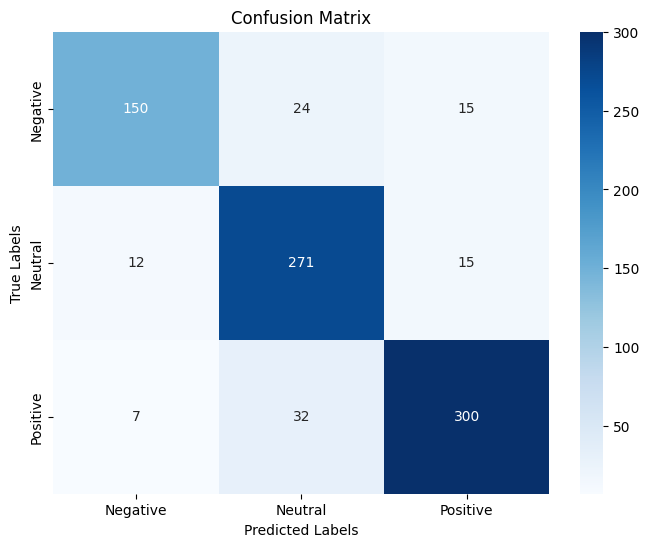

In [41]:
# Compute the confusion matrix using predicted class labels
cm = confusion_matrix(y_test, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
dt_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Accuracy: 0.8462469733656174

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.81      0.82       189
           1       0.79      0.88      0.83       298
           2       0.91      0.83      0.87       339

    accuracy                           0.85       826
   macro avg       0.85      0.84      0.84       826
weighted avg       0.85      0.85      0.85       826



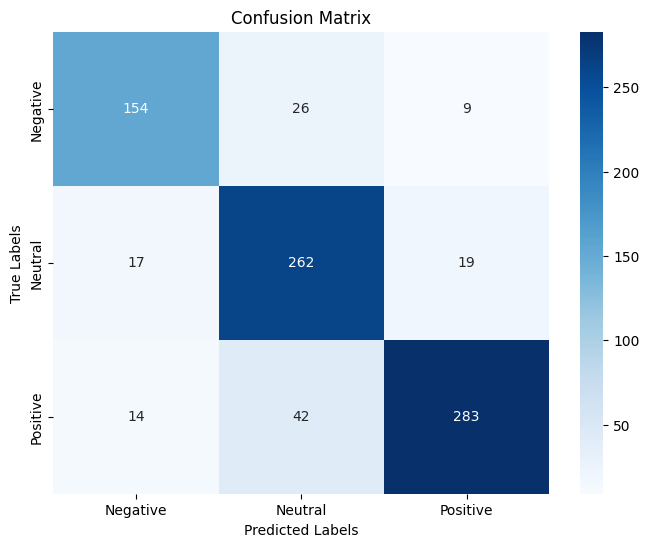

In [31]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [32]:
from sklearn.ensemble import RandomForestClassifier
# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print(f"Random Forest with {100} estimators:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest with 100 estimators:
Accuracy: 0.8631961259079903

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.81      0.84       189
           1       0.81      0.90      0.85       298
           2       0.92      0.86      0.89       339

    accuracy                           0.86       826
   macro avg       0.87      0.86      0.86       826
weighted avg       0.87      0.86      0.86       826



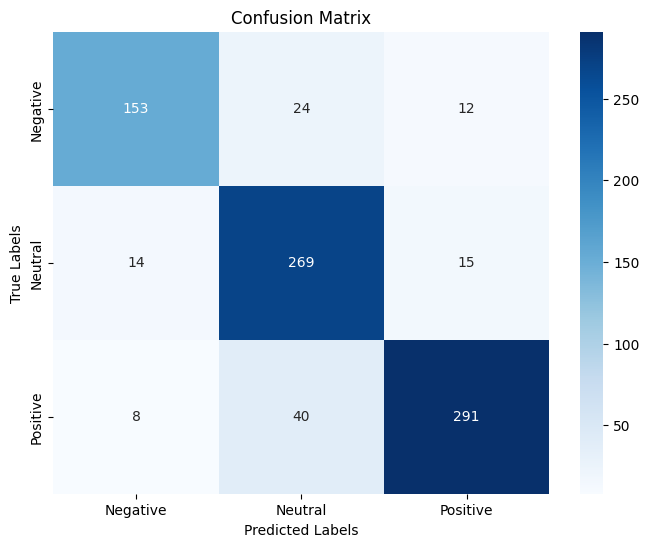

In [33]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [34]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the XGBoost model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# Train the model on the training data
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

c:\Users\DELL\Desktop\SA\myenv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:45:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8777239709443099

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.80      0.85       189
           1       0.82      0.94      0.87       298
           2       0.93      0.87      0.90       339

    accuracy                           0.88       826
   macro avg       0.88      0.87      0.87       826
weighted avg       0.88      0.88      0.88       826



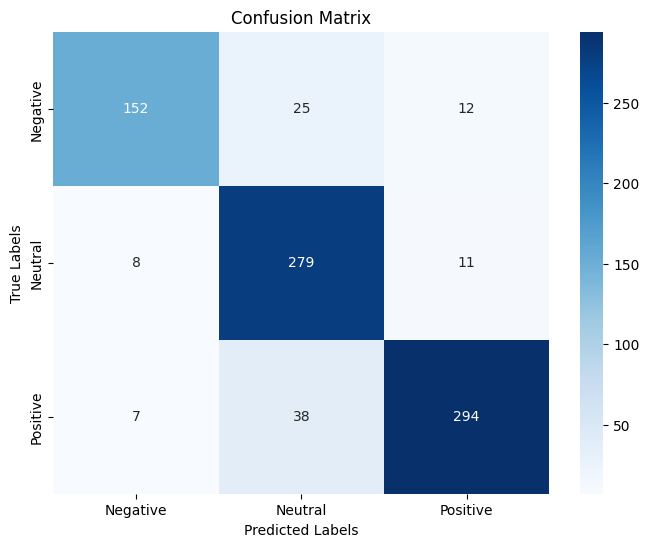

In [35]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Epoch 1/17
88/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3770 - loss: 1.0887Epoch 1: Test accuracy = 0.4455, Test loss = 1.0249
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3794 - loss: 1.0876 - val_accuracy: 0.4773 - val_loss: 1.0269
Epoch 2/17
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5199 - loss: 1.0030Epoch 2: Test accuracy = 0.6659, Test loss = 0.9141
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5201 - loss: 1.0028 - val_accuracy: 0.6858 - val_loss: 0.9140
Epoch 3/17
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6167 - loss: 0.8913Epoch 3: Test accuracy = 0.8184, Test loss = 0.8093
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6170 - loss: 0.8910 - val_accuracy: 0.7885 - val_loss: 0.8120
Epoch 4/17
89/93 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7026 - loss: 0.8034Epoch 4: Test accuracy = 0.8499, Test loss = 0.7282
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7028 - loss: 0.8032 - val_accuracy: 0.8369 - val_loss: 0.7

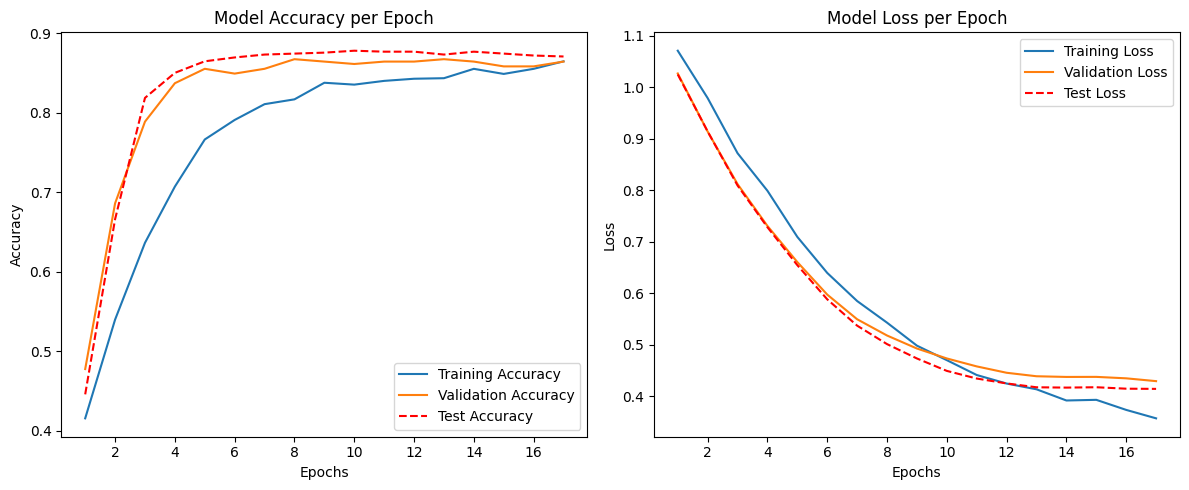

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Final Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.85       189
           1       0.81      0.93      0.87       298
           2       0.92      0.87      0.90       339

    accuracy                           0.87       826
   macro avg       0.88      0.86      0.87       826
weighted avg       0.88      0.87      0.87       826



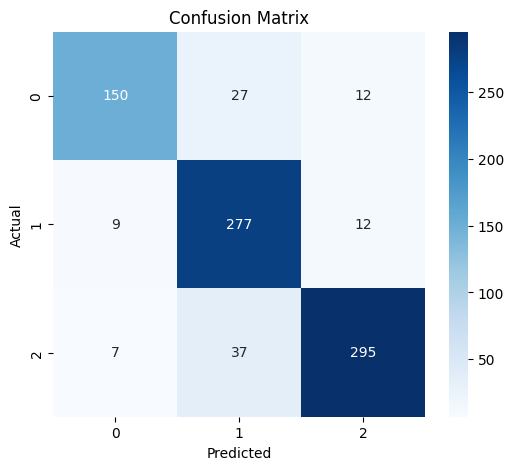

In [17]:

from keras.callbacks import ReduceLROnPlateau
from keras.optimizers.schedules import ExponentialDecay

# Custom callback to evaluate on test data after each epoch
class TestPerformanceCallback(Callback):
    def __init__(self, X_test, y_test_cat):
        super().__init__()
        self.X_test = X_test
        self.y_test_cat = y_test_cat
        self.test_accuracies = []
        self.test_losses = []

    def on_epoch_end(self, epoch, logs=None):
        loss, acc = self.model.evaluate(self.X_test, self.y_test_cat, verbose=0)
        self.test_losses.append(loss)
        self.test_accuracies.append(acc)
        print(f"Epoch {epoch+1}: Test accuracy = {acc:.4f}, Test loss = {loss:.4f}")

# Define the model model
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.0001)),
    Dropout(0.5),
    Dense(8, activation='relu', kernel_regularizer=l2(0.0001)),
    Dropout(0.5),
    Dense(3, activation='softmax', kernel_regularizer=l2(0.0001))
])


# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0003),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
test_callback = TestPerformanceCallback(X_test, y_test_cat)
reduce_lr = ReduceLROnPlateau(monitor='accuracy', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
# Define a learning rate schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.0003,
    decay_steps=1000,
    decay_rate=0.5,
    staircase=True
)

# Train the model (with validation split and test tracking)validation split and test tracking)
history = model.fit(X_train, y_train_cat,
                    epochs=17,
                    batch_size=32,
                    validation_split=0.1,
                    callbacks=[early_stop, test_callback])


# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {accuracy:.2f}")

# Plot training, validation, and test metrics
epochs_range = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(epochs_range, test_callback.test_accuracies, label='Test Accuracy', linestyle='dashed', color='red')
plt.title('Model Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
plt.plot(epochs_range, test_callback.test_losses, label='Test Loss', linestyle='dashed', color='red')
plt.title('Model Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Predict and evaluate final model
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_classes))

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



C:\Users\DELL\AppData\Local\Temp\ipykernel_28768\3277097173.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=training_times, palette='viridis')


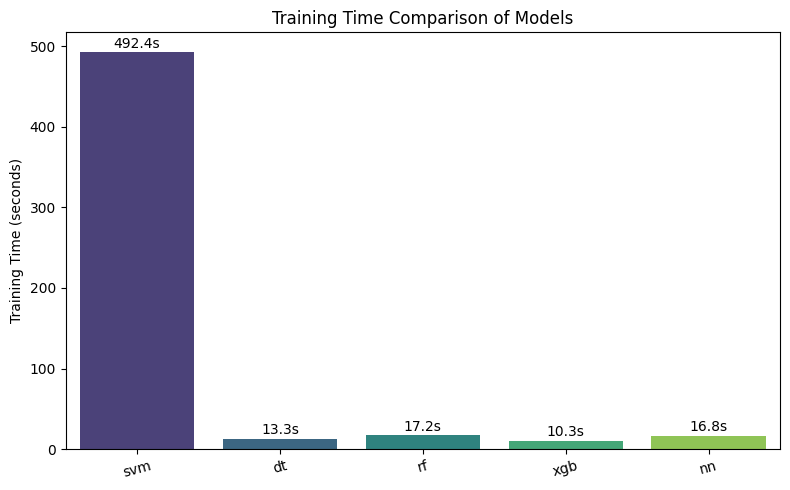

In [42]:
# Plotting the training times for each model
model_names = ['SVM', 'Decision Tree', 'Random Forest', 'XGBoost', 'Neural Network']
training_times = [4*60 + 51.3, 11.2, 17.2, 17.2, 26.4]  # times in seconds
# Update training times (in seconds)
training_times = [8*60 + 12.4, 13.3, 17.2, 10.3, 16.8]
plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=training_times, palette='viridis')
plt.ylabel('Training Time (seconds)')
plt.title('Training Time Comparison of Models')
for i, time in enumerate(training_times):
    plt.text(i, time + 2, f"{time:.1f}s", ha='center', va='bottom', fontsize=10)
# Custom x-tick labels to show "4 min 51.3s" for SVM
custom_labels = ['svm', 'dt', 'rf', 'xgb', 'nn']
plt.xticks(ticks=range(len(model_names)), labels=custom_labels, rotation=15)
plt.tight_layout()
plt.show()